![](./radar_eval/gui/resources/pics/Logo_Sykno.svg "")

# __MiRa Data Evaluation__ - ___Jupyter Notebook___

---
### __Introduction__


**MiRa Data Measurement:**

- MiRa Measurements Path (HDF5 Files): `/mira_root/mira/measurement/hdf5/`
- MiRa HDF5 Controller for interaction via MiRa Eval GUI or within the Jupyter Notebook: `/mira_root/mira/measurement/mira_hdf5_ctrl.py` (see MiRa HDF5 Controller Usage)
- The MiRa radar data is a Numpy array `radar_data_cube` with a shape of `(n_frames, n_samples_per_chirp, n_rx, n_tx, n_shape_sets)` and its `dtype` is `float32`.


**MiRa HDF5 Structure:**
- __/__
  - __Data__
    - ***Frame_Data_Cube_XXXX_ZZZZ***
      - `@delta_time`: `np.float32`
      - `@shape`: `(n_samples_per_chirp, n_rx, n_tx, n_shapes)`
      - `@timestamp`: `np.float32`
      - ...
  - __Metadata__
    - ***mira_bgt_reg_content***
      - `@mira_bgt_reg_content`:
    - ***mira_bgt_reg_content_readable***
      - `@mira_bgt_reg_content_readable`:
    - ***mira_config***
      - `@mira_config`:
    - ***mira_radar_parameters*** 
      - `mira_radar_parameters`

***Frame_Data_Cube_XXXX_ZZZZ*** where ***XXXX*** are multiples of `4095` and ***ZZZZ*** is the frame counter with values in the range $[0, 4095]$.

- ***XXXX*** $\in \{k \cdot 4095 \mid k \in \mathbb{N}, 0 \leq k \leq 9999\}$
- ***ZZZZ*** $\in \{0, 1, 2, \ldots, 4095\}$


**Radar data cube structure:**
| Dimension            | Size |
|----------------------|------|
| Number of samples    | n_samples_per_chirp $\in \{2^n \mid n \in \mathbb{N}, 6 \leq n \leq 11\}$ |
| Number of RX antennas| n_rx_active_antennas $\in \{n \mid n \in \mathbb{N}, 1 \leq n \leq 4\}$ |
| Number of TX antennas| n_tx_active_antennas $\in \{n \mid n \in \mathbb{N}, 1 \leq n \leq 2\}$ |
| Number of shape sets | n_shapes $\in \{n \mid n \in \mathbb{N}, 1 \leq n \leq 4095\}$ |
| Number of frames     | n_frames $\in \{n \mid n \in \mathbb{N}, 0 \leq n \leq 4095\}$ |


**Chirp data structure:**

| Samples      | ADC Channel 1 (RX1) |ADC Channel 2 (RX2) |ADC Channel 3 (RX3) |ADC Channel 4 (RX4) |
|-----------------|------------------------------|-----------------|------------------------------|-----------------|
| 0         | dtype=np.uint16 | dtype=np.uint16 | dtype=np.uint16 | dtype=np.uint16 |
| 1         | 12 bit ADC | 12 bit ADC | 12 bit ADC | 12 bit ADC |
| 2         | 0 - 1.2 V | 0 - 1.2 V | 0 - 1.2 V | 0 - 1.2 V |
| ...             | ...                          | ...                          | ...                          | ...                          |
| n-1         | 0 - 4095 | 0 - 4095 | 0 - 4095 | 0 - 4095 |


**Working with HDF5:**

- List measurement structure:
```sh 
    h5ls -r mira_hdf5_filename.hdf5
```
- Inspect a specific group or dataset:
```sh
    h5dump -d /Data/Frame_Data_Cube_XXXX_ZZZZ mira_hdf5_filename.hdf5
```
- Inspect measurement meta data:
```sh
    h5dump -g /Metadata mira_hdf5_filename.hdf5
```
- Get statistics e.g. number of groups, datasets, and attributes:
```sh
    h5stat mira_hdf5_filename.hdf5
```


In [1]:
description = "MiRa Root is: "
project_root = !pwd
print(f"{description}{project_root[0]}")
radar_meas_hdf5_path = f'{project_root[0]}/mira/measurement/hdf5/'
!tree -C {radar_meas_hdf5_path}

MiRa Root is: /home/jurnijasted/coding/sykno/MiRa_IFX_60GHz_2x4/sykno_radar_gui
/home/jurnijasted/coding/sykno/MiRa_IFX_60GHz_2x4/sykno_radar_gui/mira/measurement/hdf5/  [error opening dir]

0 directories, 0 files


In [2]:
radar_meas_hdf5_file_path = f'{radar_meas_hdf5_path}/SY60I13_Measurement_25_08_2024_22_54_55_Default_Session.hdf5'

In [3]:
!h5ls -r {radar_meas_hdf5_file_path}

/home/jurnijasted/coding/sykno/MiRa_IFX_60GHz_2x4/sykno_radar_gui/mira/measurement/hdf5//SY60I13_Measurement_25_08_2024_22_54_55_Default_Session.hdf5: unable to open file


In [4]:
!h5dump -d /Data/Frame_Data_Cube_0000_0001 {radar_meas_hdf5_file_path}

h5dump error: unable to open file "/home/jurnijasted/coding/sykno/MiRa_IFX_60GHz_2x4/sykno_radar_gui/mira/measurement/hdf5//SY60I13_Measurement_25_08_2024_22_54_55_Default_Session.hdf5"


In [5]:
!h5dump -g /Metadata {radar_meas_hdf5_file_path}

h5dump error: unable to open file "/home/jurnijasted/coding/sykno/MiRa_IFX_60GHz_2x4/sykno_radar_gui/mira/measurement/hdf5//SY60I13_Measurement_25_08_2024_22_54_55_Default_Session.hdf5"


In [6]:
!h5stat {radar_meas_hdf5_file_path}

Filename: /home/jurnijasted/coding/sykno/MiRa_IFX_60GHz_2x4/sykno_radar_gui/mira/measurement/hdf5//SY60I13_Measurement_25_08_2024_22_54_55_Default_Session.hdf5
h5stat error: unable to open file "/home/jurnijasted/coding/sykno/MiRa_IFX_60GHz_2x4/sykno_radar_gui/mira/measurement/hdf5//SY60I13_Measurement_25_08_2024_22_54_55_Default_Session.hdf5"


___
### __MiRa Data Evaluation__ - ___Python Code___


#### ***MiRa HDF5 Controller Usage***


In [7]:
import os
import numpy as np
import ipywidgets as widgets
from radar_eval.measurement.hdf5_controller import MIRA_HDF5_CTRL
from radar_eval.radar_system.radar_system_definition import MIRA_RADAR_PARAMETER
radar_meas_hdf5_path = './radar_eval/measurement/hdf5/'

# List all files in the folder
file_names = os.listdir(radar_meas_hdf5_path)

# Filter out non-file entries if needed
file_names = [f for f in file_names if os.path.isfile(os.path.join(radar_meas_hdf5_path, f)) and f != '.gitkeep']
sorted_file_names = sorted(file_names)

# Dropdown for file selection
file_dropdown = widgets.Dropdown(
    options=file_names,
    description=f'Select a File:',
)
print((f'MiRa HDF5 Files in {radar_meas_hdf5_path}:'))
file_dropdown.layout.width = '650px'  # Adjust the width as needed
display(file_dropdown)



MiRa HDF5 Files in ./radar_eval/measurement/hdf5/:


Dropdown(description='Select a File:', layout=Layout(width='650px'), options=('SY60I13_Measurement_25_08_2024_…

In [8]:
from pathlib import Path
hdf5_controller = MIRA_HDF5_CTRL(Path(radar_meas_hdf5_path+str(file_dropdown.value)).resolve())
data = hdf5_controller.read_dataset("/Data/Frame_Data_Cube_0000_0023")
print(data)

[[[[2060. 2060. 2060. ... 2060. 2064. 2062.]]

  [[2048. 2047. 2048. ... 2046. 2046. 2046.]]

  [[2038. 2036. 2038. ... 2036. 2038. 2036.]]]


 [[[2006. 2011. 2004. ... 2002. 2006. 2010.]]

  [[2058. 2053. 2050. ... 2055. 2052. 2052.]]

  [[2049. 2048. 2050. ... 2050. 2048. 2048.]]]


 [[[1980. 1996. 1984. ... 1978. 1991. 1996.]]

  [[2084. 2076. 2074. ... 2078. 2074. 2068.]]

  [[2078. 2073. 2078. ... 2080. 2074. 2074.]]]


 ...


 [[[1958. 1958. 1958. ... 1956. 1958. 1960.]]

  [[1854. 1854. 1855. ... 1857. 1857. 1856.]]

  [[1970. 1966. 1968. ... 1972. 1972. 1968.]]]


 [[[1962. 1964. 1964. ... 1962. 1960. 1962.]]

  [[1854. 1854. 1854. ... 1856. 1856. 1856.]]

  [[1972. 1971. 1968. ... 1972. 1971. 1968.]]]


 [[[1970. 1968. 1968. ... 1970. 1968. 1970.]]

  [[1857. 1859. 1857. ... 1860. 1860. 1859.]]

  [[1975. 1976. 1975. ... 1976. 1976. 1974.]]]]


In [9]:
hdf5_controller.print_hdf5_structure()

2024-08-25 23:47:57.076 | DEBUG    | radar_eval.measurement.hdf5_controller:_print_structure:76 - - /
2024-08-25 23:47:57.077 | DEBUG    | radar_eval.measurement.hdf5_controller:_print_structure:76 -   - Data
2024-08-25 23:47:57.079 | DEBUG    | radar_eval.measurement.hdf5_controller:_print_structure:92 -     - Frame_Data_Cube_0000_0000 (Dataset)
2024-08-25 23:47:57.080 | DEBUG    | radar_eval.measurement.hdf5_controller:_print_structure:99 -       - @delta_time: 0.1805717945098877
2024-08-25 23:47:57.081 | DEBUG    | radar_eval.measurement.hdf5_controller:_print_structure:99 -       - @shape: (256, 3, 1, 64)
2024-08-25 23:47:57.082 | DEBUG    | radar_eval.measurement.hdf5_controller:_print_structure:99 -       - @timestamp: 1724619296.077177
2024-08-25 23:47:57.084 | DEBUG    | radar_eval.measurement.hdf5_controller:_print_structure:92 -     - Frame_Data_Cube_0000_0001 (Dataset)
2024-08-25 23:47:57.085 | DEBUG    | radar_eval.measurement.hdf5_controller:_print_structure:99 -       - @

In [10]:
stats = hdf5_controller.get_dataset_statistics("/Data/Frame_Data_Cube_0000_0001")
print(stats)

{'mean': np.float32(1902.014), 'std_dev': np.float32(273.02695), 'min': np.float32(1403.0), 'max': np.float32(2540.0)}


In [11]:
info = hdf5_controller.get_dataset_info("/Data/Frame_Data_Cube_0000_0000")
print(info)

((256, 3, 1, 64), dtype('<f4'))


In [12]:
frame_data_cube = hdf5_controller.get_dataset_slice("/Data/Frame_Data_Cube_0000_0000")

In [29]:
metadata = hdf5_controller.read_metadata()
print(metadata['mira_bgt_reg_content'])

{'mira_bgt_reg_content': 'reg 0x00 0x1e9390\nreg 0x01 0x0a0210\nreg 0x02 0x000303\nreg 0x03 0x000000\nreg 0x04 0xe967fd\nreg 0x05 0x0805b4\nreg 0x06 0x1537ff\nreg 0x07 0x010900\nreg 0x08 0x000050\nreg 0x0c 0x000050\nreg 0x10 0x13fc51\nreg 0x13 0x000000\nreg 0x17 0x000000\nreg 0x1a 0x000000\nreg 0x1e 0x000000\nreg 0x21 0x000000\nreg 0x25 0x000000\nreg 0x28 0x000000\nreg 0x09 0x000000\nreg 0x0d 0x000000\nreg 0x11 0x7f1610\nreg 0x14 0x000210\nreg 0x18 0x000210\nreg 0x1b 0x000210\nreg 0x1f 0x000210\nreg 0x22 0x000210\nreg 0x26 0x000210\nreg 0x29 0x000210\nreg 0x0a 0x000000\nreg 0x0e 0x000000\nreg 0x12 0x808421\nreg 0x15 0x808421\nreg 0x19 0x808421\nreg 0x1c 0x808421\nreg 0x20 0x808421\nreg 0x23 0x808421\nreg 0x27 0x808421\nreg 0x2a 0x808421\nreg 0x0b 0x000080\nreg 0x0f 0x000080\nreg 0x16 0x000090\nreg 0x1d 0x000080\nreg 0x24 0x000080\nreg 0x2b 0x000080\nreg 0x2c 0xa6fed9\nreg 0x2d 0x3cd4bf\nreg 0x2e 0x03f000\nreg 0x2f 0xa9a538\nreg 0x30 0xaa0000\nreg 0x38 0xaa0000\nreg 0x40 0x000000\nreg 0

In [14]:
radar_param: MIRA_RADAR_PARAMETER = hdf5_controller.unpickle_metadata()
print(radar_param)

In [15]:
mira_data_cube = np.array(hdf5_controller.load_radar_data_cube(), dtype=np.float32)
print(mira_data_cube.shape, mira_data_cube.dtype)

(374, 256, 3, 1, 64) float32


---
#### ***Inspect MiRa Dataset***

1. **Load python packages and MiRa HDF5 measurement file**


2. **Open MiRa HDF5 measurement file, load meta data and build radar data cube**

3. **MiRa HDF5 measurement - data profiling**

    __Inspect MiRa Radar System Parameters__
    - __radar_param__: meta-class contains __All__ other sub-classes
        - __sys__: sub-class contains __Radar__ specific values
        - __dsp__: sub-class contains __DSP__ parameters
        - __mon__: sub-class to __Monitor__ frame count, duration time, etc.
        - __gui__: sub-class contains __GUI__ relevant parameters
        - __meas__: sub-class contains __Measurement__ relevant parameters
        - __remt__: sub-class contains __Remote Control__ relevant parameters
        - __rply__: sub-class contains __Replay Control__ relevant parameters 

In [16]:
print(f"{radar_param.__dict__=}")
print(f"{radar_param.dsp.__dict__=}")
print(f"{radar_param.gui.__dict__=}")
print(f"{radar_param.mon.__dict__=}")
print(f"{radar_param.sys.__dict__=}")
print(f"{radar_param.meas.__dict__=}")
print(f"{radar_param.remt.__dict__=}")
print(f"{radar_param.rply.__dict__=}")

radar_param.__dict__={'gui': <radar_eval.radar_system.radar_system_definition.MIRA_RADAR_GUI_PARAMETER object at 0x79c53cfe3cd0>, 'dsp': <radar_eval.radar_system.radar_system_definition.MIRA_RADAR_DSP_PARAMETER object at 0x79c53cfe36a0>, 'sens': <radar_eval.radar_system.radar_system_definition.MIRA_RADAR_SENS_PARAMETER object at 0x79c53cfe3b50>, 'sys': <radar_eval.radar_system.radar_system_definition.MIRA_RADAR_SYS_PARAMETER object at 0x79c53cfe3f10>, 'mon': <radar_eval.radar_system.radar_system_definition.MIRA_RADAR_MON_PARAMETER object at 0x79c53c538640>, 'meas': <radar_eval.radar_system.radar_system_definition.MIRA_RADAR_MEAS_PARAMETER object at 0x79c53c5386d0>, 'rply': <radar_eval.radar_system.radar_system_definition.MIRA_RADAR_RPLY_PARAMETER object at 0x79c53c538700>, 'remt': <radar_eval.radar_system.radar_system_definition.MIRA_RADAR_REMT_PARAMETER object at 0x79c53c538760>}
radar_param.dsp.__dict__={'axis_max_value': np.uint32(0), 'padding_len': 512, 'window_func': 'hanning', 'a

3. **MiRa HDF5 measurement - data profiling**

    2. __Check MiRa Radar System Parameters__
    - __radar_param__: meta-class contains __All__ other sub-classes

In [17]:
print(f"{mira_data_cube.shape=}")
print(f"{frame_data_cube.shape=}\n" + \
      f"{hdf5_controller.delta_time=}\n" + \
      f"{hdf5_controller.shape=}\n" + \
      f"{hdf5_controller.timestamp=}")

print(f"{frame_data_cube[:1,:,:,0]}")


mira_data_cube.shape=(374, 256, 3, 1, 64)
frame_data_cube.shape=(256, 3, 1, 64)
hdf5_controller.delta_time=None
hdf5_controller.shape=None
hdf5_controller.timestamp=None
[[[2061.]
  [2046.]
  [2038.]]]


---
#### ***Postprocessing MiRa Data***

##### 1. **Load MiRa Processing Module and create a Data Processor**

In [18]:
from radar_eval.processing.radar_data_processing import MIRA_DATA_PROCESSOR
mira_data_processor = MIRA_DATA_PROCESSOR(radar_param)

mira_data_processor.padding_len = 0
mira_data_processor.data_preprocessor.init_window(window_func='hanning')
mira_data_processor.data_preprocessor.init_dsp_hp_filter(order=7, filter_type='sos', cutoff=100e3)


##### 2. **Time Singal Processing**

In [19]:
scaled_raw_data = mira_data_processor.scale_raw_data(mira_data_cube[1,...], preprocessing=False, output_mean=False)
print(f"{scaled_raw_data.shape=}")
scaled_raw_data_mean = mira_data_processor.scale_raw_data(mira_data_cube[1,...], preprocessing=False, output_mean=True)
print(f"{scaled_raw_data_mean.shape=}")
scaled_raw_data_preprocessed = np.zeros_like(mira_data_cube)
for f in range(mira_data_cube.shape[0]):
    scaled_raw_data_preprocessed[f,...] = mira_data_processor.scale_raw_data(mira_data_cube[f,...], preprocessing=True, output_mean=False)
    
print(f"{scaled_raw_data_preprocessed.shape=}")
scaled_raw_data_preprocessed_mean = mira_data_processor.scale_raw_data(mira_data_cube[1,...], preprocessing=True, output_mean=True)
print(f"{scaled_raw_data_preprocessed_mean.shape=}")

scaled_raw_data.shape=(256, 3, 1, 64)
scaled_raw_data_mean.shape=(256, 3, 1)
scaled_raw_data_preprocessed.shape=(374, 256, 3, 1, 64)
scaled_raw_data_preprocessed_mean.shape=(256, 3, 1)


In [20]:
%matplotlib inline
import matplotlib.pyplot as plt
import ipywidgets as widgets
from ipywidgets import interact
import numpy as np


def plot_tx_rx_lines_with_mean(data, plot_title_note: str='', 
                               x_label: str='Time (μs)', 
                               y_label: str='Voltage (mV)',
                               style: str='dark_background'):
    num_tx = data.shape[2]
    num_rx = data.shape[1]
    x_max = 100  # Assuming a ramp time of 100 μs for demonstration purposes
    x_values = np.linspace(0, x_max, data.shape[0])
    
    with plt.style.context(style):
        for tx in range(num_tx):
            # Initialize the plot for each transmitter
            plt.figure(figsize=(10, 6))
            
            # Iterate over the receivers to plot each as a separate line
            for rx in range(num_rx):
                plt.plot(x_values, data[:, rx, tx], label=f'TX{tx+1}_RX{rx+1}')
            
            # Calculate and plot the mean over all RX/TX pairs
            mean_data = np.mean(data, axis=(1, 2))
            plt.plot(x_values, mean_data, label='Mean RX/TX', linestyle='--', color='white')
            
            # Adding labels and title
            plt.xlabel(x_label)
            plt.ylabel(y_label)
            plt.title(f'Plot of TX{tx+1} with {num_rx} RX Lines {plot_title_note}')
            
            # Adding legend
            plt.legend()
            
            # Show the plot
            plt.show()

def interactive_plot(frame_num, shape_num):
    try:
        # Generate scaled data dynamically based on the frame number
        scaled_raw_data = mira_data_processor.scale_raw_data(mira_data_cube[frame_num,...], preprocessing=False, output_mean=False)
        scaled_raw_data_preprocessed = mira_data_processor.scale_raw_data(mira_data_cube[frame_num,...], preprocessing=True, output_mean=False)

        plot_tx_rx_lines_with_mean(scaled_raw_data[..., shape_num])
        # plot_tx_rx_lines_with_mean(scaled_raw_data_preprocessed[..., shape_num])
    except Exception as e:
        print(f"Error: {e}")

# Create widgets for frame and shape number selection
frame_slider = widgets.IntSlider(value=0, min=0, max=mira_data_cube.shape[0] - 1, step=1, description='Frame Num:')
shape_slider = widgets.IntSlider(value=0, min=0, max=mira_data_cube.shape[4] - 1, step=1, description='Shape Num:')

# Display the widgets for dataset and parameters selection
display(widgets.VBox([frame_slider, shape_slider]))

# Create interactive plot function
interact(interactive_plot, 
         frame_num=frame_slider,
         shape_num=shape_slider)


interactive(children=(IntSlider(value=0, description='Frame Num:', max=373), IntSlider(value=0, description='S…

<function __main__.interactive_plot(frame_num, shape_num)>

In [21]:
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from matplotlib import animation
from IPython.display import HTML

# Generate dummy data for demonstration
# scaled_raw_data_preprocessed = np.random.rand(64, 4, 2, 512)  # [samples, rx, tx, frames]
mpl.rcParams['animation.embed_limit'] = 10000
# Extract dimensions
num_samples, num_rx, num_tx, num_frames = scaled_raw_data.shape

# Prepare the figure and axes
fig, axs = plt.subplots(num_tx, figsize=(10, 6 * num_tx), sharex=True, constrained_layout=True)
plt.style.use('dark_background')

if num_tx == 1:
    axs = [axs]  # Make it iterable for a single transmitter case

# Initialize lines for each rx in tx plots and set initial data
lines = []
for tx in range(num_tx):
    for rx in range(num_rx):
        line, = axs[tx].plot(np.arange(num_samples), scaled_raw_data[:, rx, tx, 0], label=f'RX{rx+1}')
        lines.append(line)
    axs[tx].set_title(f'TX{tx+1}')
    axs[tx].legend(loc='upper right')
    axs[tx].set_xlabel('Samples')
    axs[tx].set_ylabel('Amplitude')
    axs[tx].set_xlim(0, num_samples-1)
    axs[tx].set_ylim(np.min(scaled_raw_data), np.max(scaled_raw_data))

# Define animation update function
def update(frame):
    idx = 0
    for tx in range(num_tx):
        for rx in range(num_rx):
            lines[idx].set_ydata(scaled_raw_data[:, rx, tx, frame])
            idx += 1
    return lines


# Modify the update function call within FuncAnimation
ani = animation.FuncAnimation(fig, update, frames=[i for i in tqdm(range(num_frames))], interval=100)


plt.close(fig)
# Display the animation
# HTML(ani.to_jshtml())


100%|██████████| 64/64 [00:00<00:00, 523266.00it/s]


In [22]:
import numpy as np

# Function to check and overwrite slices
def clear_data(arr):
    frame_correction_dict = {
        'counter': 0,
        'position': [],
    }
    # Iterate over dimensions 0, 2, 3, and 4
    for frame_index in range(1, arr.shape[0], 1):  # dim 0
        for rx_index in range(arr.shape[2]):  # dim 2
            for tx_index in range(arr.shape[3]):  # dim 3
                for shape_index in range(1, arr.shape[4]):  # dim 4, start from 1 to be able to refer to the previous slice
                    # Check if all elements along dim 1 are zeros for the given slice
                    if np.all(arr[frame_index, :, rx_index, tx_index, shape_index] == 0):
                        # Overwrite with the values from the previous slice in dim 4
                        # print(arr[i, :, j, k, l])
                        arr[frame_index, :, rx_index, tx_index, shape_index] = arr[frame_index, :, rx_index, tx_index, shape_index-1]
                        frame_correction_dict['position'].append((shape_index,rx_index,tx_index,shape_index))
                        frame_correction_dict['counter'] += 1
                        # print('clear up', f"{frame_index=}, {rx_index=}, {tx_index=}, {shape_index=}, {frame_correction_dict['counter']}")
    return frame_correction_dict

# Apply the function to your array
# frame_correction_result = clear_data(mira_data_cube)
# print(frame_correction_result)



##### 3. **Spectrum Singal Processing**

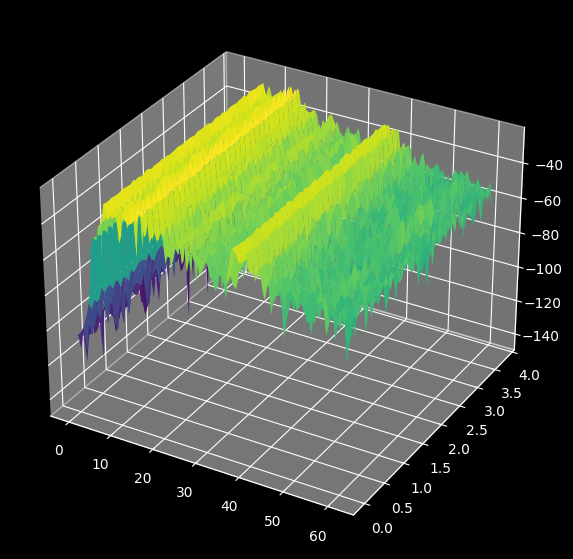

In [23]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import animation
from IPython.display import HTML
c = 0
mira_data_cube = scaled_raw_data_preprocessed
for i in range(mira_data_cube.shape[0]):
    for ii in range(mira_data_cube.shape[4]):
        is_zero = np.any(np.all(mira_data_cube[i, :, 0, 0, ii] == 0))
        if is_zero:
            c+=1
            
spectrum = mira_data_processor._calc_rfft_channels(mira_data_cube.transpose((1,2,3,4,0)))
subset = spectrum[:, 0, 0, :, :]  
subset = subset.transpose(1,0,2)

# Create meshgrid for the x and y dimensions
x = np.arange(0, (radar_param.sys.frame_duration * 1e3), (radar_param.sys.frame_duration * 1e3)/subset.shape[1])  # Note the change to match 'subset' dimensions
y = np.arange(0, radar_param.sys.max_range, radar_param.sys.max_range/subset.shape[0])
x, y = np.meshgrid(x, y)

# Initialize 3D plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# Initial plot
surf = ax.plot_surface(x, y, subset[:, :, 0], cmap='viridis')  # Initial Z-data

# Update function for animation
def update(frame):
    ax.clear()
    ax.plot_surface(x, y, subset[:, :, frame], cmap='viridis')
    ax.set_xlabel('Range (m)')
    ax.set_ylabel('Time (ms)')
    ax.set_zlabel('Magnetude (dB)')
    ax.set_title('3D Waterfall spectrogram')

    # Optionally, set the same zlim for each frame to have consistent scaling
    ax.set_zlim(-20, 40)

# Create animation
# ani = animation.FuncAnimation(fig, update, frames=subset.shape[2], interval=100)
# ani.save('./radar_eval/measurement/animation/animation.mp4', writer='ffmpeg', fps=10)
# Close the plot to prevent it from displaying statically
# plt.close()

# Display the animation
# HTML(ani.to_jshtml(fps=10))


##### 4. **Spectrogram Signal Processing**


In [24]:
print(f"{mira_data_cube.shape=}")
for frame in range(mira_data_cube.shape[0]-1):
    spectrogram_map_1 = mira_data_processor._calc_spectogram(mira_data_cube[frame+1,:,:,0,:])
mira_data_processor.spectogram_map = np.zeros((1,1,1), dtype=np.float32)
for frame in range(mira_data_cube.shape[0]-1):
    spectrogram_map_2 = mira_data_processor._calc_spectogram(mira_data_cube[frame+1,:,:,1,:])
spectrogram_map = np.stack((spectrogram_map_1, spectrogram_map_2), axis=-1)
del spectrogram_map_1, spectrogram_map_2
print(f"{spectrogram_map.shape=}")

mira_data_cube.shape=(374, 256, 3, 1, 64)


IndexError: index 1 is out of bounds for axis 3 with size 1

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact

# Assuming 'radar_param' and 'spectrogram_map' are defined in your context
# And assuming 'spectrogram_map' is your numpy array with shape (frames, time, range, rx, tx)

# Titles for each subplot
x_min, x_max = 0, radar_param.sys.max_range  # microseconds
y_min, y_max = 0, radar_param.sys.frame_duration * 1e3  # milliseconds

# Calculate the extent for imshow
extent = [x_min, x_max, y_min, y_max]

def plot_mean_spectrogram(frame_num):
    with plt.style.context('dark_background'):
        # Set up the figure
        fig, ax = plt.subplots(figsize=(15, 10))  # Modified the figsize for better visibility
        
        # Calculate the mean over all RX/TX pairs
        mean_dataset = np.mean(spectrogram_map[:, :, :, :], axis=(2,3))
        
        # Plot the dataset
        im = ax.imshow(mean_dataset, cmap='jet', aspect='auto', extent=extent, origin='lower')

        # Set the title for the subplot
        ax.set_title(f"Mean Spectrogram for Frame {frame_num}", color='white')
        
        # Add a colorbar
        cbar = fig.colorbar(im, ax=ax)
        cbar.ax.yaxis.set_tick_params(color='white')
        cbar.outline.set_edgecolor('white')
        for text in cbar.ax.yaxis.get_ticklabels():
            text.set_color('white')

        # Set axis labels
        ax.set_xlabel('Range (m)')
        ax.set_ylabel('Time (ms)')

    # Adjust layout to prevent overlap
    plt.tight_layout()
    plt.show()

# Create widget for frame number selection
frame_slider = widgets.IntSlider(value=0, min=0, max=spectrogram_map.shape[0] - 1, step=1, description='Frame Num:')

# Display the widget for frame number selection
display(frame_slider)

# Create interactive plot function
interact(plot_mean_spectrogram, frame_num=frame_slider)


NameError: name 'spectrogram_map' is not defined

In [26]:
# TODO Implement some interactive features to jupyter notebook
import ipywidgets as widgets
from IPython.display import display
import datetime
import matplotlib.pyplot as plt
import numpy as np

# Example datasets
datasets = {
    'Sine Wave': np.sin,
    'Cosine Wave': np.cos
}

# Dropdown for dataset selection
dataset_dropdown = widgets.Dropdown(
    options=list(datasets.keys()),
    value='Sine Wave',
    description='Dataset:',
)

# Slider for frequency adjustment
frequency_slider = widgets.FloatSlider(
    value=1.0,
    min=0.1,
    max=5.0,
    step=0.1,
    description='Frequency:',
)

# Function to update plot
def update_plot(dataset_name, frequency):
    plt.clf() # Clear the current figure
    func = datasets[dataset_name] # Get the function to use
    x = np.linspace(0, 2 * np.pi, 1000)
    y = func(frequency * x)
    plt.plot(x, y)
    plt.show()

# Interactive widget
widgets.interactive_output(update_plot, {'dataset_name': dataset_dropdown, 'frequency': frequency_slider})

# Display widgets
display(dataset_dropdown, frequency_slider)

# Button widget
button = widgets.Button(description="Click Me!")
def on_button_clicked(b):
    print("Button clicked.")

button.on_click(on_button_clicked)

# Accordion widget
accordion = widgets.Accordion(children=[widgets.IntSlider(), widgets.Text()])
accordion.set_title(0, 'Slider')
accordion.set_title(1, 'Text')

display(button, accordion)


Dropdown(description='Dataset:', options=('Sine Wave', 'Cosine Wave'), value='Sine Wave')

FloatSlider(value=1.0, description='Frequency:', max=5.0, min=0.1)

Button(description='Click Me!', style=ButtonStyle())

Accordion(children=(IntSlider(value=0), Text(value='')), titles=('Slider', 'Text'))

Processing frames and TXs:   0%|          | 0/90 [00:00<?, ?it/s]/tmp/ipykernel_26685/2296011928.py:39: UserWarning: Input data is complex, switching to return_onesided=False
  f, t, Zxx = stft(signal, fs=frame_rate, window='hann', nperseg=32, noverlap=16, nfft=512)
Processing frames and TXs: 100%|██████████| 90/90 [00:10<00:00,  8.93it/s]


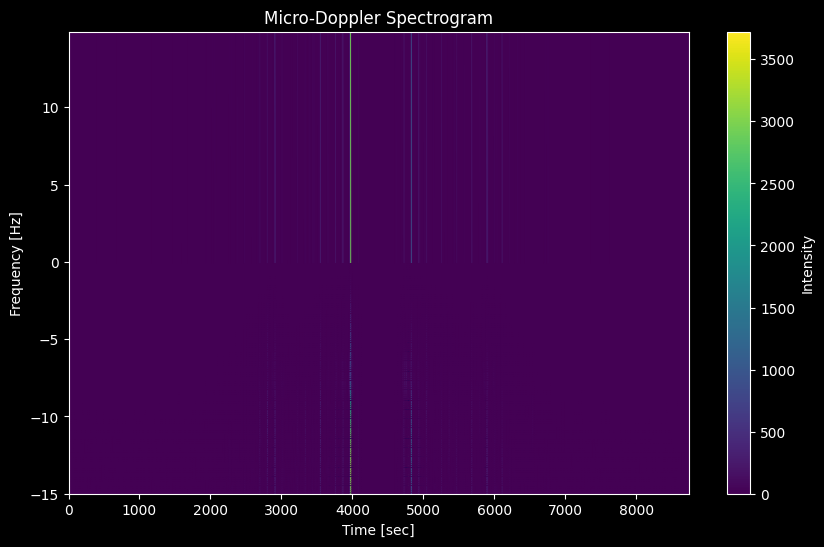

ERROR:__main__:An error occurred: too many indices for array: array is 2-dimensional, but 3 were indexed


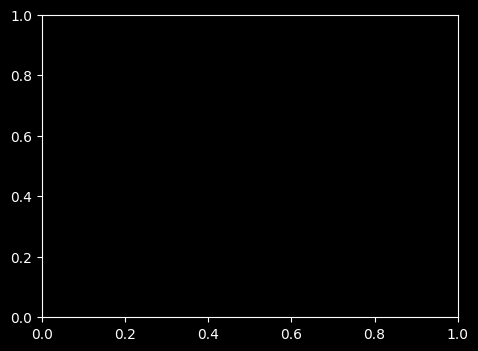

In [ ]:
# Import necessary libraries
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import stft, windows
from numpy.fft import fft, fftshift
import logging
from tqdm import tqdm
import ipywidgets as widgets
from ipywidgets import interact

# Setup logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

# FFT processing function with optional windowing
def fft_process(data, n_fft=None, axis=-1, window=True):
    if window:
        win = windows.hann(data.shape[axis])
        win_shape = np.ones(data.ndim, dtype=int)
        win_shape[axis] = data.shape[axis]
        win = win.reshape(win_shape)
        data = data * win
    return fftshift(fft(data, n=n_fft, axis=axis), axes=axis)

# Function to generate micro-Doppler data
def generate_micro_doppler(data_cube, fft_range, fft_doppler, frame_rate):
    f_list, t_list, Zxx_list = [], [], []
    
    total_frames = data_cube.shape[0] * data_cube.shape[3]
    with tqdm(total=total_frames, desc="Processing frames and TXs") as pbar:
        for frame in range(data_cube.shape[0]):
            for tx in range(data_cube.shape[3]):
                data_tx = data_cube[frame, :, :, tx, :]
                ranged_fft = fft_process(data_tx, n_fft=fft_range, axis=0)
                doppler_fft = fft_process(ranged_fft, n_fft=fft_doppler, axis=2)
                
                # Use the processed Doppler FFT data for STFT
                signal = doppler_fft.ravel()
                f, t, Zxx = stft(signal, fs=frame_rate, window='hann', nperseg=32, noverlap=16, nfft=512)
                
                f_list.append(f)
                t_list.append(t + frame / frame_rate)  # Adjust the time axis
                Zxx_list.append(Zxx)
                
                pbar.update(1)
    
    # Concatenate the results
    f = f_list[0]  # Frequency axis is the same for all frames
    t = np.concatenate(t_list)
    Zxx = np.concatenate(Zxx_list, axis=-1)
    
    # Downsample Zxx for plotting
    downsample_factor_time = 25  # Example downsample factor for time
    downsample_factor_freq = 2    # Example downsample factor for frequency
    
    Zxx_downsampled = Zxx[:, ::downsample_factor_time]
    f_downsampled = f[::downsample_factor_freq]
    Zxx_downsampled = Zxx_downsampled[::downsample_factor_freq, :]
    t_downsampled = t[::downsample_factor_time]

    return f_downsampled, t_downsampled, Zxx_downsampled

# Plotting function for micro-Doppler data
def plot_micro_doppler(f, t, Zxx):
    plt.figure(figsize=(10, 6))
    plt.pcolormesh(t, f, np.abs(Zxx), shading='gouraud')
    plt.title('Micro-Doppler Spectrogram')
    plt.ylabel('Frequency [Hz]')
    plt.xlabel('Time [sec]')
    plt.colorbar(label='Intensity')
    plt.show()

# Radar processing parameters
fft_range = 512
fft_doppler = 128
frame_rate = 30  # Assuming a frame rate of 30 frames per second

# Sample data cube (replace this with actual data)
data_cube = mira_data_cube

# Generate and plot the micro-Doppler data
try:
    f, t, Zxx = generate_micro_doppler(data_cube, fft_range, fft_doppler, frame_rate)
    plot_micro_doppler(f, t, Zxx)
except Exception as e:
    logger.error(f"An error occurred: {e}")

# Function to visualize micro-Doppler with an interactive slider
def microdoppler_visualizer(uDoppler):
    fig, ax = plt.subplots()
    plt.subplots_adjust(left=0.25, bottom=0.25)
    img = plt.imshow(uDoppler[:, 0, :], aspect='auto')
    ax.margins(x=0)
    
    srange = widgets.IntSlider(min=0, max=uDoppler.shape[1] - 1, step=1, value=0, description='Range:')
    
    def update_range(change):
        r = change['new']
        img.set_data(uDoppler[:, r, :])
        img.autoscale()
        fig.canvas.draw_idle()
    
    srange.observe(update_range, names='value')
    
    display(srange)
    plt.show()

# Visualize the accumulated uDoppler map
try:
    microdoppler_visualizer(Zxx)
except Exception as e:
    logger.error(f"An error occurred: {e}")
